In [3]:
# Borra consola, variables y funciones definidas en el entorno Global
cat("\014")
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());

In [4]:
#carga librerías
library("lattice")
library("ggplot2")
library("latex2exp")
suppressMessages(library("crayon"))

#si no están instaladas, usar: install.packages("crayon", dependencies = T)
#obvio, cambiar crayon por las librerías que necesiten

#tamaño de la figura en Jupyter
fig <- function(width, heigth) {
    options(repr.plot.width = width, repr.plot.height = heigth)
}
fig(26,14);

In [5]:
#tema de graficación
library("ggplot2")
temajuan <- theme(
  legend.position = c(0.14, 0.80),
  legend.background = element_blank(),
  legend.title = element_text(size = 22),
  legend.box = "horizontal",
  legend.direction = "vertical",
  plot.title = element_text(size = 18),
  #legend.key.height = unit(0.1,"snpc"),
  legend.key.width  = unit(0.125,"snpc"),
  #legend.box.spacing = unit(0.1,"snpc"),
  legend.key = element_blank(),
  legend.spacing.x = unit(10, "pt"),
  legend.text = element_text(size = 24, margin = margin(t = 0, r= 5,b = 0, l = 3, unit = "pt")),
  axis.line = element_line(size = 0.5, lineend = "square"),
  axis.title = element_text(size = 24),
  axis.text.x = element_text(size = 18, colour = "black", angle = 0,  vjust = 1),
  axis.text.y = element_text(size = 18, colour = "black"),
  axis.ticks = element_line(size = 1, colour = "black"),
  panel.border = element_rect(size = 1, fill = NA)
)  

In [6]:
dirDatos <- "/home/juan/Documentos/Docencia/fexpi/2024/DatosLabo2/"
dirGraf <- "/home/juan/Documentos/Docencia/FEXPgit/FexpI/Análisis de Datos/Labo2/Graf/"

## Labo 2

Como siempre en física, tenemos un modelo (de péndulo simple en este caso):

$$
\tau = 2\pi \sqrt{\dfrac{l}{g}}
$$

donde:

* $\tau \; [s]$ es el periodo del péndulo.

* $l \; [m]$ es el largo del péndulo.

* $g \; [m \, s^{-2}\,]$ es la aceleración de la gravedad a la que está sometido el péndulo.

La idea es que queremos ver si funciona, o cómo funciona (bien, mal, más o menos).

## Labo 2

Lo que hicimos el lunes fue:

1. Hacer un péndulo de largo $l_{cm} \; $.

2. Medir 200 veces $\tau$ usando un cronómetro.

Ahora deberíamos ver si el modelo funciona:

1. Para cada medida individual.

2. Para todo el curso.

## Medida Individual - Cargando valores

Voy a trabajar con la medida de Facundo, luego cargo los datos de todo el curso.
* Nombre de columnas en la primera fila: Lap, Lap Time, Total Time
* Valores separadas por coma (ok).


In [7]:
#Directorio de trabajo
setwd(dirDatos); list.files()

[1] "Fabri_pendulo.csv" "FacuM.csv"         "Graf"             
 [4] "p_Agustin.csv"     "p_Alvaro.csv"      "p_Brenda.csv"     
 [7] "p_brisa.csv"       "p_Fedra.csv"       "p_Felipe.csv"     
[10] "p_Franco.csv"      "p_Marcelo.csv"     "p_nahuel.csv"     
[13] "p_Navratil.txt"    "p_Rogel.csv"       "p_Tijera.csv"     
[16] "Todos"

In [8]:
readLines(con = "p_Alvaro.csv", n = -1) #leemos 5 líneas del archivos(hacerlo siempre en un Notepad);

[1] "Stopwatch Pro"             "August 26, 2024 12:01"    
  [3] ""                          "Time: 07:41.81"           
  [5] ""                          "Lap,Total time,Difference"
  [7] "1,00:01.84,00:01.84"       "2,00:04.11,00:02.27"      
  [9] "3,00:06.49,00:02.38"       "4,00:08.77,00:02.28"      
 [11] "5,00:11.10,00:02.33"       "6,00:13.41,00:02.31"      
 [13] "7,00:15.60,00:02.19"       "8,00:17.95,00:02.35"      
 [15] "9,00:20.27,00:02.32"       "10,00:22.51,00:02.24"     
 [17] "11,00:24.83,00:02.32"      "12,00:27.11,00:02.28"     
 [19] "13,00:29.56,00:02.45"      "14,00:31.73,00:02.17"     
 [21] "15,00:34.13,00:02.40"      "16,00:36.39,00:02.26"     
 [23] "17,00:38.80,00:02.41"      "18,00:41.13,00:02.33"     
 [25] "19,00:43.36,00:02.23"      "20,00:45.65,00:02.29"     
 [27] "21,00:48.08,00:02.43"      "22,00:50.51,00:02.43"     
 [29] "23,00:52.72,00:02.21"      "24,00:54.98,00:02.26"     
 [31] "25,00:57.28,00:02.30"      "26,00:59.58,00:02.30"     
 [33] "27,01:01.91,00:02.33"      "28,01:04.21,00:02.30"     
 [35] "29,01:06.51,00:02.30"      "30,01:08.87,00:02.36"     
 [37] "31,01:11.14,00:02.27"      "32,01:13.39,00:02.25"     
 [39] "33,01:15.65,00:02.26"      "34,01:18.09,00:02.44"     
 [41] "35,01:20.51,00:02.42"      "36,01:22.74,00:02.23"     
 [43] "37,01:24.93,00:02.19"      "38,01:27.27,00:02.34"     
 [45] "39,01:29.48,00:02.21"      "40,01:31.78,00:02.30"     
 [47] "41,01:34.15,00:02.37"      "42,01:36.51,00:02.36"     
 [49] "43,01:38.72,00:02.21"      "44,01:41.02,00:02.30"     
 [51] "45,01:43.42,00:02.40"      "46,01:45.67,00:02.25"     
 [53] "47,01:47.86,00:02.19"      "48,01:50.14,00:02.28"     
 [55] "49,01:52.60,00:02.46"      "50,01:54.89,00:02.29"     
 [57] "51,01:57.09,00:02.20"      "52,01:59.42,00:02.33"     
 [59] "53,02:01.75,00:02.33"      "54,02:04.03,00:02.28"     
 [61] "55,02:06.33,00:02.30"      "56,02:08.62,00:02.29"     
 [63] "57,02:11.03,00:02.41"      "58,02:13.31,00:02.28"     
 [65] "59,02:15.52,00:02.21"      "60,02:17.86,00:02.34"     
 [67] "61,02:20.18,00:02.32"      "62,02:22.46,00:02.28"     
 [69] "63,02:24.81,00:02.35"      "64,02:27.16,00:02.35"     
 [71] "65,02:29.34,00:02.18"      "66,02:31.75,00:02.41"     
 [73] "67,02:33.96,00:02.21"      "68,02:36.24,00:02.28"     
 [75] "69,02:38.67,00:02.43"      "70,02:40.92,00:02.25"     
 [77] "71,02:43.31,00:02.39"      "72,02:45.58,00:02.27"     
 [79] "73,02:47.86,00:02.28"      "74,02:50.21,00:02.35"     
 [81] "75,02:52.48,00:02.27"      "76,02:54.70,00:02.22"     
 [83] "77,02:57.12,00:02.42"      "78,02:59.43,00:02.31"     
 [85] "79,03:01.69,00:02.26"      "80,03:03.99,00:02.30"     
 [87] "81,03:06.20,00:02.21"      "82,03:08.58,00:02.38"     
 [89] "83,03:10.95,00:02.37"      "84,03:13.23,00:02.28"     
 [91] "85,03:15.55,00:02.32"      "86,03:17.77,00:02.22"     
 [93] "87,03:20.13,00:02.36"      "88,03:22.43,00:02.30"     
 [95] "89,03:24.70,00:02.27"      "90,03:27.10,00:02.40"     
 [97] "91,03:29.47,00:02.37"      "92,03:31.67,00:02.20"     
 [99] "93,03:34.05,00:02.38"      "94,03:36.26,00:02.21"     
[101] "95,03:38.42,00:02.16"      "96,03:40.75,00:02.33"     
[103] "97,03:43.12,00:02.37"      "98,03:45.47,00:02.35"     
[105] "99,03:47.76,00:02.29"      "100,03:50.07,00:02.31"    
[107] "101,03:52.35,00:02.28"     "102,03:54.61,00:02.26"    
[109] "103,03:57.02,00:02.41"     "104,03:59.32,00:02.30"    
[111] "105,04:01.59,00:02.27"     "106,04:03.83,00:02.24"    
[113] "107,04:06.19,00:02.36"     "108,04:08.48,00:02.29"    
[115] "109,04:10.73,00:02.25"     "110,04:13.06,00:02.33"    
[117] "111,04:15.43,00:02.37"     "112,04:17.66,00:02.23"    
[119] "113,04:20.08,00:02.42"     "114,04:22.36,00:02.28"    
[121] "115,04:24.62,00:02.26"     "116,04:26.86,00:02.24"    
[123] "117,04:29.25,00:02.39"     "118,04:31.54,00:02.29"    
[125] "119,04:33.81,00:02.27"     "120,04:36.14,00:02.33"    
[127] "121,04:38.43,00:02.29"     "122,04:40.80,00:02.37"    
[129] "123,04:43.04,00:02.24"     

## LOS FORMATOS IGUALES!

Les voy a mostrar datos del año pasado...la discusión va a ser la misma.

Al cargar datos:

* El formato de los tiempos se carga como texto...porque es formato horario (HH:MM:SS), pero lo tenemos que pasar a segundos.

In [9]:
#cargamos datos
d <- read.csv(file = "p_Alvaro.csv", sep = ",", header = T, skip = 5); head(d,10)

,Lap,Total.time,Difference
,<int>,<fct>,<fct>
1,1,00:01.84,00:01.84
2,2,00:04.11,00:02.27
3,3,00:06.49,00:02.38
4,4,00:08.77,00:02.28
5,5,00:11.10,00:02.33
6,6,00:13.41,00:02.31
7,7,00:15.60,00:02.19
8,8,00:17.95,00:02.35
9,9,00:20.27,00:02.32


In [10]:
#cambio nombres de columnas
colnames(d) <- c("n", "tiempootal", "tau")

d <- d[, -2]; 

#nos deshacemos de los dos puntos
tau <- gsub(x = d$tau, pattern = ":", replacement = "");
tau <- as.numeric(tau);

d$tau <-  tau; head(d,3) #reasignamos segundos como un número

,n,tau
,<int>,<dbl>
1,1,1.84
2,2,2.27
3,3,2.38


### Actividad 4.2: Sobre los resultados de la medida de $\tau$.

a. Según lo afirmado en la ec.(1.1.1), el periodo τ no cambia. ¿Esto está reflejado en el gráfico de dispersión τ vs. el número de medida?, ¿muestra alguna tendencia τ en función del número de medida  si crece o decrece), o aparece una nube de puntos sin correlación entre sı́?


In [11]:
#pinto en rojo los valores anómalos
gtau <- ggplot() +
geom_point(data = d, aes(x = n, y = tau)) + 
#geom_point(data = d[d$tau > 3.15 | d$tau < 2.705, ],aes(x = n, y = tau), colour = "Red2", size = 5) +
geom_hline(aes(yintercept = mean(tau)), colour = "Green3", lwd = 2) + 
ylab(TeX("$\\tau \\, (s)$")) + 
temajuan

fig(16,9)

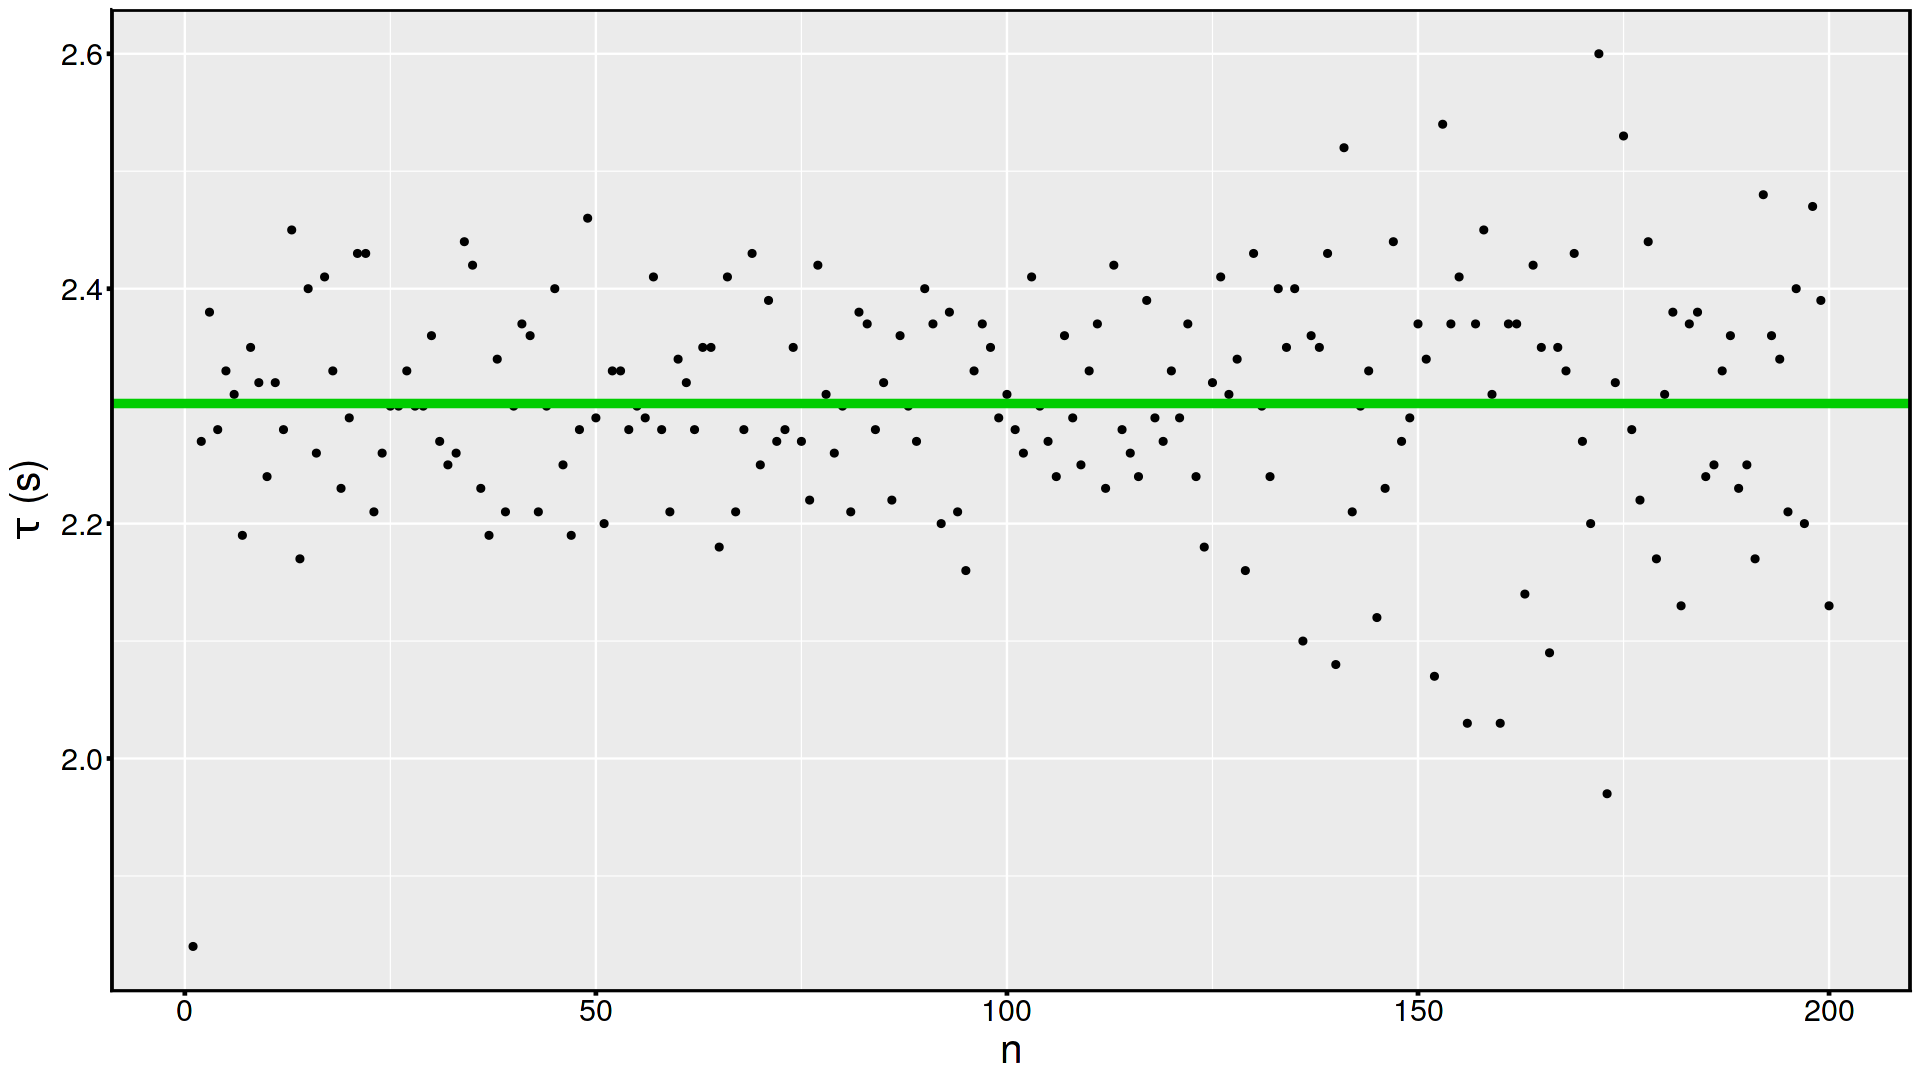

In [12]:
show(gtau)

**b.** En lugar de elegir una de las medidas τ i , se elige la media muestral τ como mejor estimador del periodo. ¿qué razones hay para esto? ¿que podrı́a malir sal ? Si hay errores (equivocaciones) en la muestra, la media muestral se sesga. Es bueno limpiar (quitar, sacar) los valores mal medidos antes de calcular la media.

In [ ]:
tau_mediasucia = mean(d$tau); sd_sucia = sd(d$tau);
cat(red$bold("periodo medio = ", mean(d$tau), "s ; sd = ", sd(d$tau), " s"))


* En el  hay algunos valores muy separados: les decimos valores ***anómalos*** ó ***atípicos*** (o en inglés ***outliers***).

El problema es que los valores anómalos nos *sesgan* la media (ni hablar la desviación estándar)


* Miramos el histograma rapidito

In [13]:
ghtau <- ggplot(data = d, aes(x = tau)) + 
geom_histogram(alpha = 0.4, fill = "DeepSkyBlue4", colour = NA, lwd = 0, bins = nclass.Sturges(d$tau)) +
temajuan + xlab(TeX("$\\tau \\, (s)$")) + ylab("Frecuencia") + 
scale_y_continuous(expand = expansion(mult = c(0, .1)))

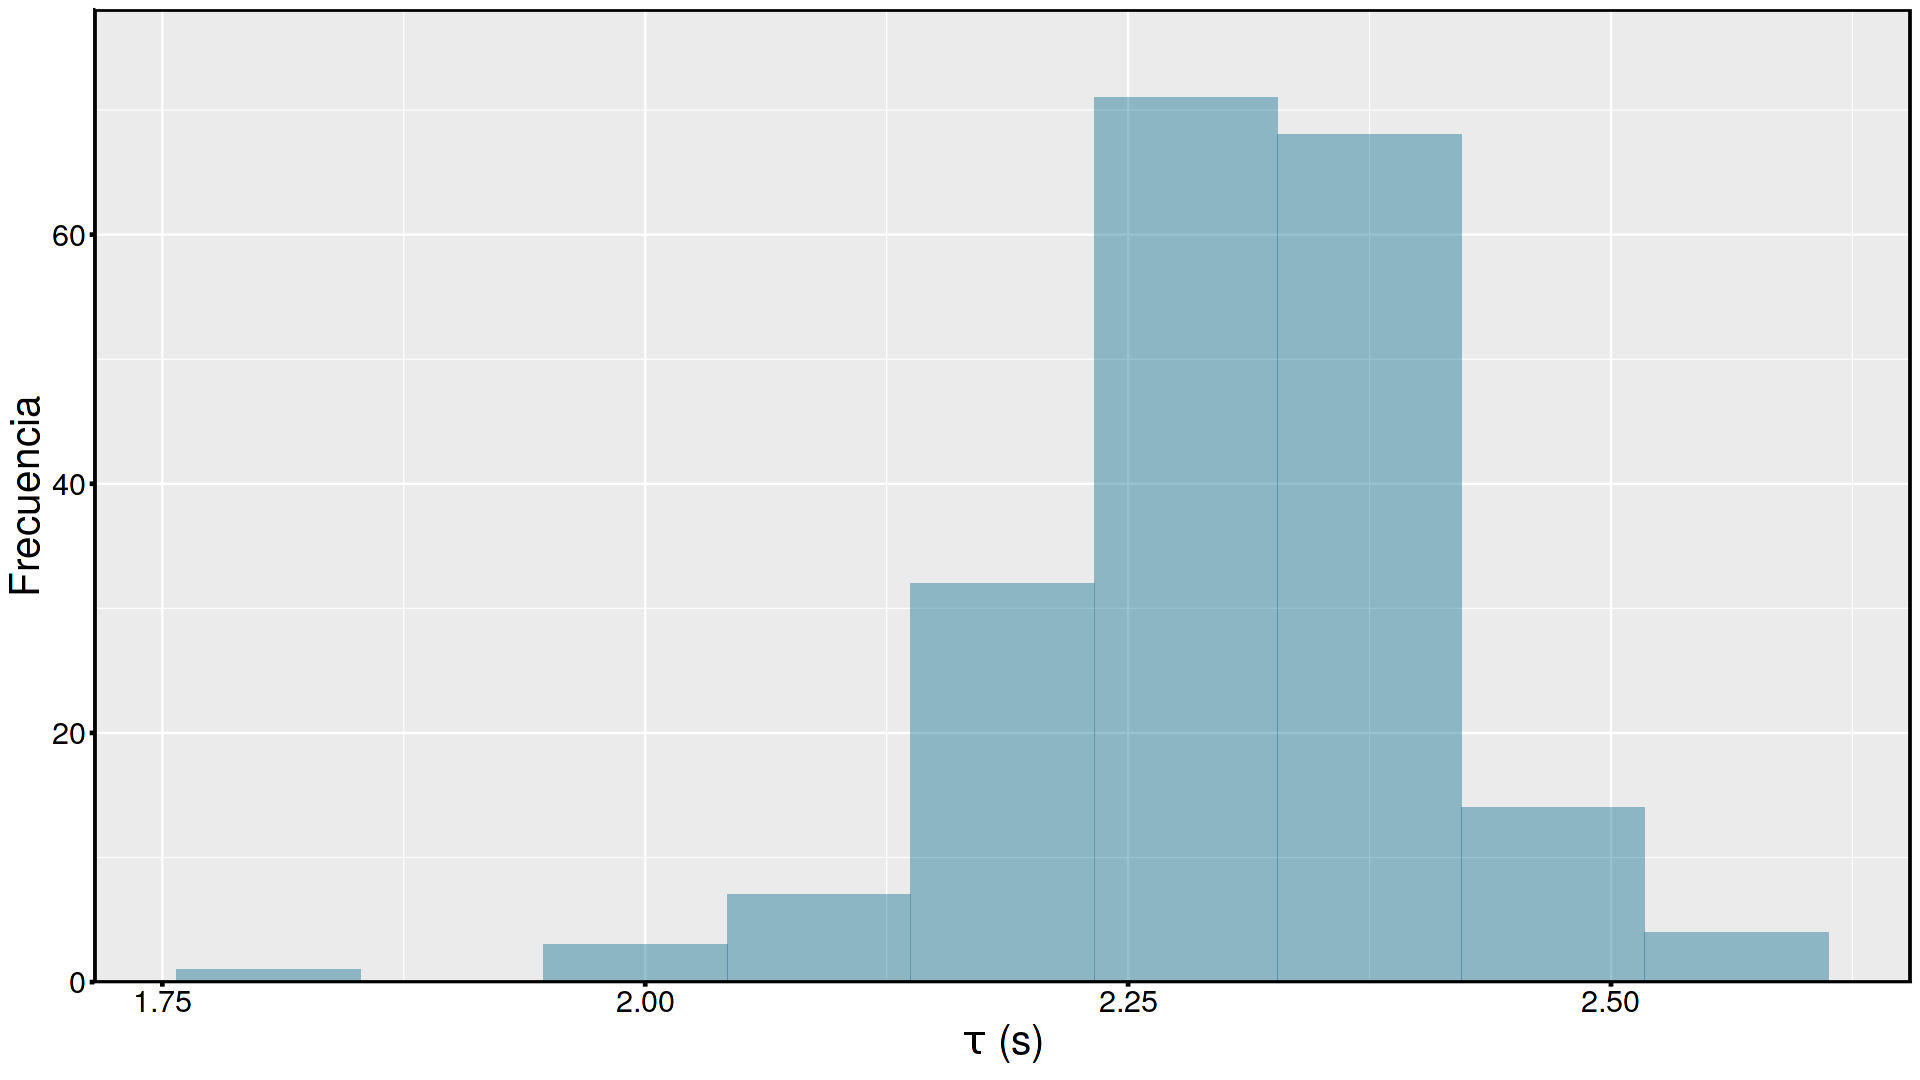

In [14]:
suppressMessages(show(ghtau))

Se ve que hay un par de puntos a la derecha ($\tau > 4s$), que viven en lugares raros: alejados de todas las medidas, solitarios, meditabundos, excluídos de toda cercanía de **continuidad** con la medida. 

Estos valores son **anómalos** o **atípicos** o (en inglés) **outlier** y generalmente se sacan de los datos.

Si los sacamos....

In [15]:
dlimpio <- d[d$tau > 2, ]; 
cat(red$bold("Datos sucios : periodo medio = ", round(mean(d$tau), 4), "s  ; Desviación estándar = ", sd(d$tau), "s\n\n"))
cat(blue$bold("Datos Limpios: periodo medio = ", round(mean(dlimpio$tau),4), "s  ; Desviación estándar = ", sd(dlimpio$tau), "s \n\n"))
cat(green$bold("  Media Sucia - Media Limpia = ",round(mean(d$tau) - mean(dlimpio$tau),14),"s  ;  s_sucia - s_limpia  = ", sd(d$tau) - sd(dlimpio$tau), " s"))

Datos sucios : periodo medio =  2.3022 s  ; Desviación estándar =  0.101569974889211 s

Datos Limpios: periodo medio =  2.3062 s  ; Desviación estándar =  0.0935992870672995 s 

  Media Sucia - Media Limpia =  -0.00401161616162 s  ;  s_sucia - s_limpia  =  0.0079706878219116  s

* Los valores atípicos o anómalos sesgan mucho:

    * A la media muestral la **mueven**(dependiendo de dónde estén los datos anómalos), en este caso poco, porque hay datos anómalos a izquierda y a derecha.
    
    * A la desviación estándar de la muestra la **vuelan**: dos datos (de doscientos) nos cambian la desviación estándar y la reducen al ~ 30% de su valor original.

*****
*****

###  Valores Atípicos ó Anómalos en una medida

* Los valores anómalos se **sacan** (es un estilo brutal, pero estilo al fin).

* Hay métodos para esto:

   1. Sacarlos *a mano* es ***engorroso***
   2. Si hay muchos datos de distinta procedencia, es ***imposible***.
   3. Es importante *mostrar el criterio para identificar valores atípicos*, para que no sea un criterio que sea ***el que se nos antoja en el momento*** (aunque por ahora parece ser así).
   
Sin embargo, por ahora los sacamos.   

In [16]:
ghtau <- ggplot() + 
 geom_histogram(data = dlimpio,aes(tau),bins = nclass.Sturges(tau), colour = "Black", alpha = 0.4, lwd = 0.2, show.legend = F) + #la capa del histograma
  geom_vline(data = dlimpio, aes(xintercept = mean(tau), colour = "tau media" ), lwd = 1.5 ) + 
  scale_colour_manual(values = c("tau media" = "Red3"), labels = list(TeX("$\\bar{\\tau}$")), name = NULL) +
  ylab("Frecuencia") + xlab(TeX("$\\tau \\; (s)$"))  + 
  ggtitle("Medidas del Periodo") + 
  temajuan

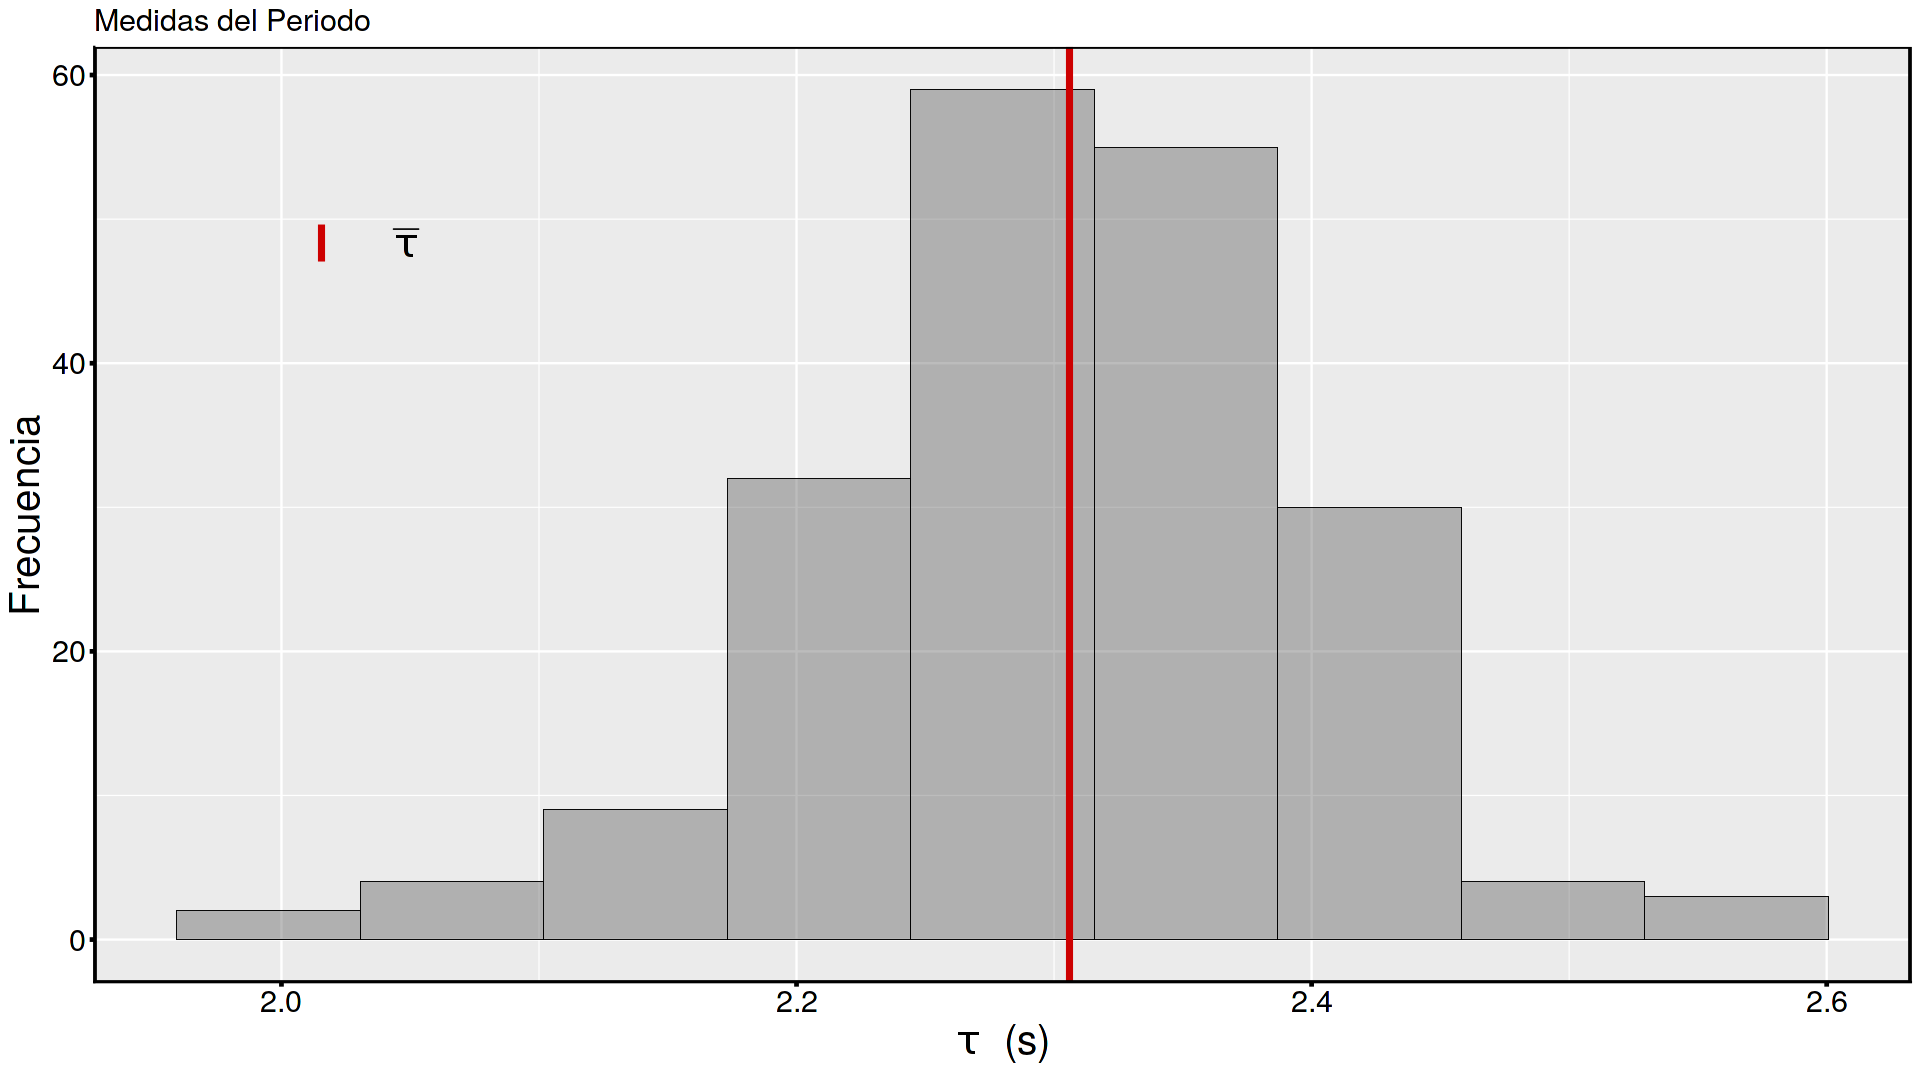

In [17]:
fig(width = 16,9); show(ghtau)

**c.** La dispersión de valores es debida a los reflejos que tenemos como homo sapiens. Una medida posible de esos reflejos, es medir la desviación estándar de la distribución obtenida. Nuevamente –y de manera  más vigorosa– la desviación estándar es muy poco robusta respecto de errores de medición. Si no hay valores anómalos (y los reflejos ante el estı́mulo visual son normales), la desviación estándar deberı́a estar en el intervalo $$\mathbf{0.07s < s_{\tau} < 0.15s}$$

lo que usaremos como comprobación de que los datos están bien limpios...

In [18]:
sd(dlimpio$tau)

[1] 0.09359929

"Álvaro el cornométrico, el pulsador más rápido del Oeste (argento)".

<img src="https://i.guim.co.uk/img/media/04b505094e0a90b0e7a4425587487ba1b4dbf703/1133_24_1227_1533/master/1227.jpg?width=700&quality=85&auto=format&fit=max&s=0922c6d5fc78c5723fe01b791597cad9" width="300"/>

d. Para la incerteza en la media muestral, en lugar de elegir la desviación estándar de la muestra de medidas, se elige el error estándar de la media, o SEM (Standart Error of the Mean, por sus siglas en inglés). Esto se debe a un teorema llamado el Teorema del Lı́mite Central. Defina formalmente al error estándar de la media (ESM en español ó, Standard Error of the Mean, en inglés). Informe el SEM para su media τ , y escriba la medida con su incerteza,

$$
\overline\tau ± SEM_{\overline{\tau}}
$$

Esto es para después (lo ven el viernes)...pero lo anotamos acá:
$$
SEM = \frac{s_{\tau}}{\sqrt{n}}
$$


In [19]:
cat(bold$blue("\nT +- SEM = (", mean(dlimpio$tau),"+-", sd(dlimpio$tau)/sqrt(nrow(dlimpio)), ") s"))


T +- SEM = ( 2.30616161616162 +- 0.00665181168437423 ) s

**e.** Supongamos que se mide el periodo τ otra vez, una misma cantidad de repeticiones, en condiciones idénticas ¿la media muestral entregará el mismo valor o uno diferente? ¿cómo es posible relacionar esto con el error estándar de la media SEM ?

Ni por asomo: si Facundo mide otra vez no va a obtener la misma media muestral...es porque la ***media muestral*** es una cantidad ***aleatoria*** como las medidas mismas de Facundo. Sin embargo, la *variación* de la **media muestral** es *menor* que la *variación* de las **medidas**.

El SEM cuantifica probabilidades de variación de la media muestral, aunque lo veremos luego.

### 4.3 Calculando y comparando un valor de Álvaro
Calcule, mediante l cm ± δl cm y τ ± SEM τ el valor de g ± δg, despejando la ec.(5.2.1). Informe este valor y compárelo con el valor de la RAGA.

$$
g_{Modelo} \;= 4\pi^2 \frac{l_{cm}}{\overline{\tau}\,^2}
$$

In [20]:
lcm <- 0.500 #lcm Facundo
dlcm <- 0.001 #incerteza de escala
tau <- 1.42518 #periodo medio facundo
dtau <- 0.0066 #error estándar de la media facundo
g_modelo <- 4*pi^2*(lcm / tau^2); #cuenta para sacar g
dg <- 4*pi^2* (1/(tau^2) * dlcm + 0.5* (lcm / tau^3)* dtau) #cuenta para sacar la icnerteza en g.

cat("g +- sg = (", g_modelo, "+-", dg, ") m s^-2")

g +- sg = ( 9.7183 +- 0.04193929 ) m s^-2

 Y listo, comparamos valores (cuando los tengamos).

****
****

# El mismo análisis para todo el curso

pero cuya salida sea una tabla de periodos y nombres, de la forma:

|Nombre|$\tau$|$SEM_\tau$ |$l_{cm}$|$\delta l_{cm}$|$l_{min}$|$l_{max}$|
|---|---|---|---|---|---|---|
|Facundo|1.42|$0.007$|1.01m|0.001|0.95|1.05|

In [21]:
## DATOS 2024, finalmente
setwd(paste0(dirDatos, "Todos/"))
dt <- read.csv("p_tutti.csv", sep = ",", header = T);
head(dt,3); tail(dt, 3)
colnames(dt) <- c("l", "T", "Nombre")

,l_m,T_s,Nombre
,<dbl>,<dbl>,<fct>
1,0.3,1.66,Marcelo
2,0.3,1.47,Marcelo
3,0.3,1.46,Marcelo


,l_m,T_s,Nombre
,<dbl>,<dbl>,<fct>
2945,2.12,5.11,Nahuel
2946,2.12,1.87,Nahuel
2947,2.12,3.06,Nahuel


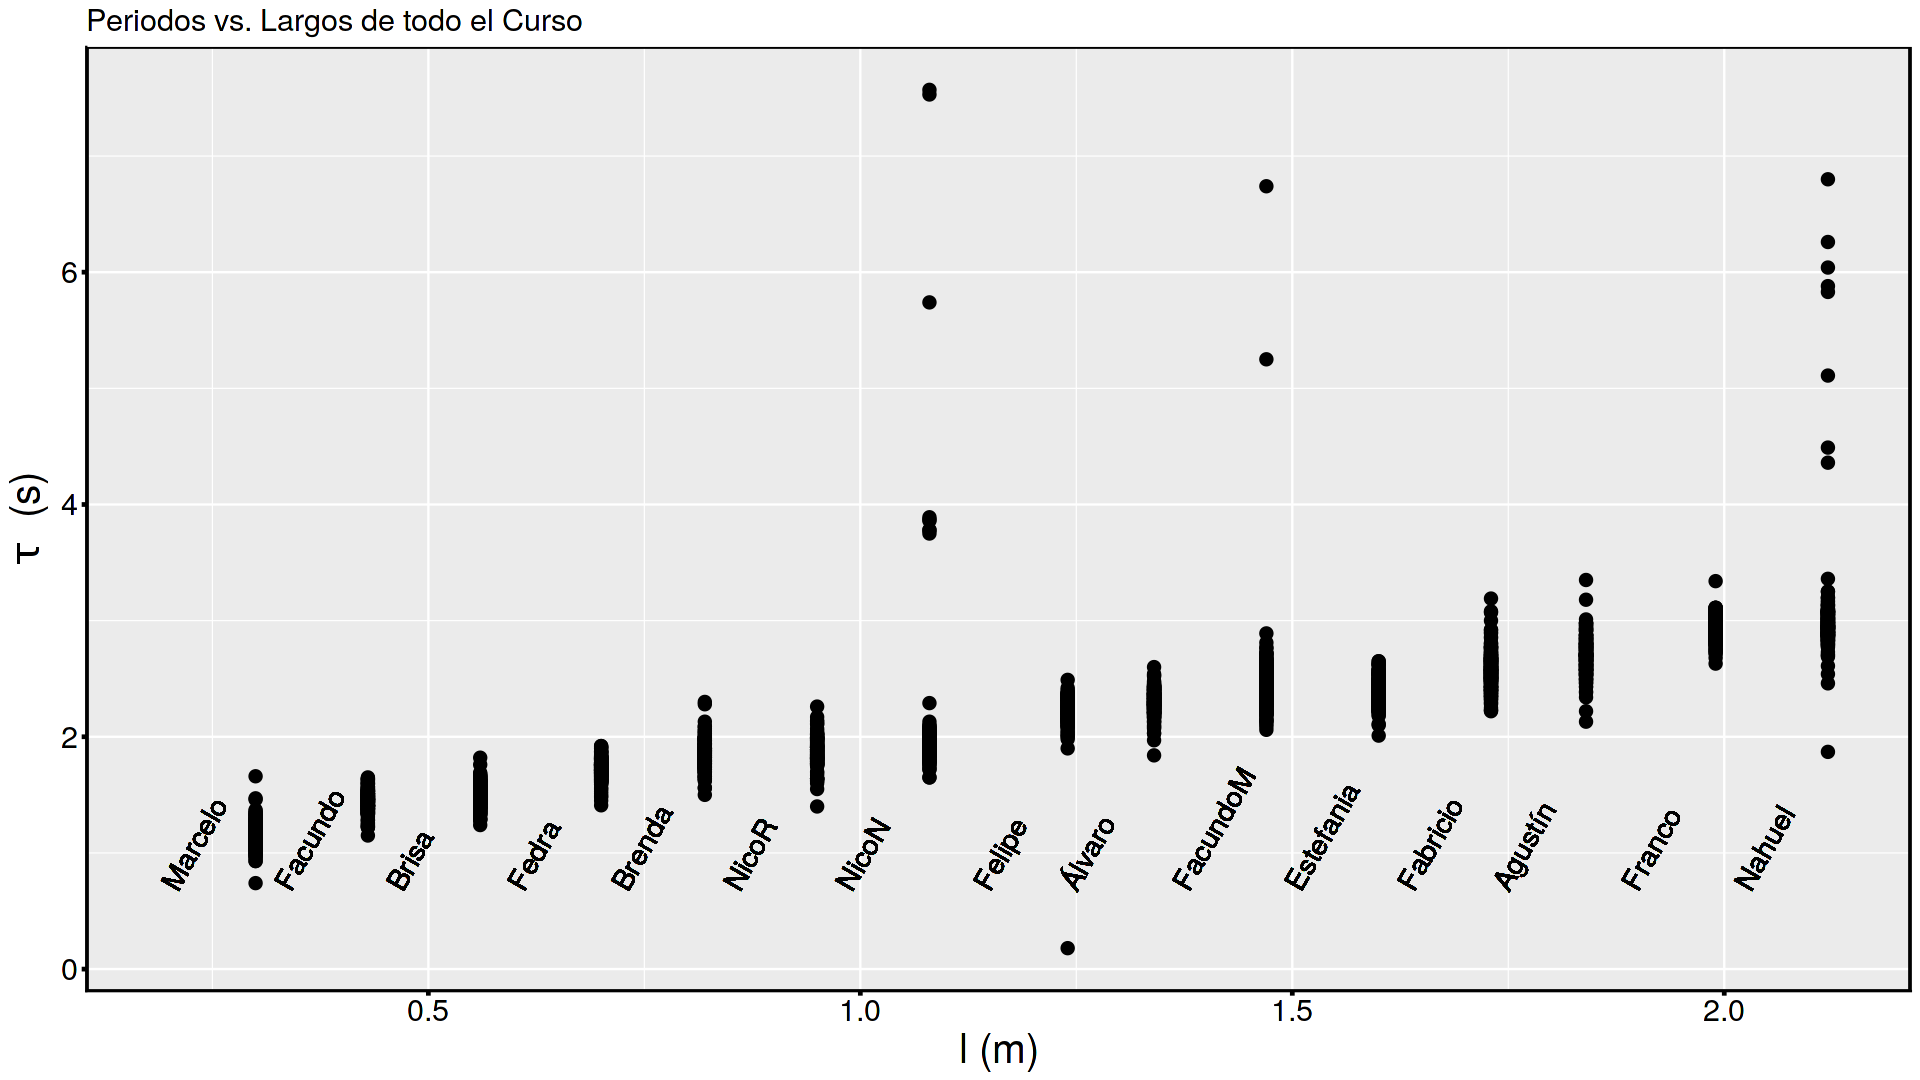

In [22]:
ggplot(data = dt, aes(x = l, y = T)) + temajuan + geom_point(size = 3) +
geom_text(aes(x = l, y = rep(0.7, nrow(dt)), angle = 60, label = Nombre), size = 6, hjust = 0, nudge_x = -0.1) +  
xlab("l (m)") + ylab(TeX("$\\tau \\; (s)$")) + ggtitle("Periodos vs. Largos de todo el Curso") +
theme(legend.direction = "horizontal", legend.position = "top")

*****
*****
### Limpiar datos

Con todo el curso es más difícil (en realidad engorroso) limpiar datos: deberíamos ver un ***gráfico*** por ***persona***, identificar valores anómalos y sacarlos a mano, generalmente poniendo algún intervalo.

Si intentamos sacar puntos pensando un intervalo centrado en la media +- 3 ó 4 desviaciones estándar, tenemos que:

* La media de cada conjunto de datos ya está sesgada.
* La desviación estándar con los datos anómalos generalmente es muy grande... y los valores anómalos entran en el intervalo propuesto.

**Una forma alternativa**:
Como sabemos la áxima desviación de los datos de periodos para personas estándar (jejeje), necesitamos
Usar un intervalo que sea $(mediana - 3 x 0.13 s, mediana + 3 x 0.13 s) $, donde $0.13 s$ es el intervalo que sabemos para el tiempo de reacción de una persona (todes ustedes son normales...)...

Todo lo que esté dentro de este intervalo (en la medida de cada uno de uds, se queda. Lo que está afuera, lo tiramos.

**[¿La mediana?](https://es.wikipedia.org/wiki/Mediana_(estad%C3%ADstica))**

La mediana se puede pensar -por ahora- como la siguiente receta:
1. Dada una lista de $x_1, x_2,...,x_n$ números, ordenarla
1. Se va desde el primer elemento de la lista, hasta el elemento que está ubicado en:
    1. Si n es **impar**, hasta el elemento que está en la mitad de la lista, es decir $x_{(n+1)/2}$.
    1. Si n es **par**, se toma el promedio de los dos elementos en la mitad de la lista $\frac{x_{\;n/2}\;\; + \;x_{\;n/2 + 1}}{2}$

El número dado por A ó B, es la mediana de la colección de datos.

La mediana (en este caso) intenta pegarle a la *media que deberíamos tener* sin los valores anómalos.

In [23]:
#calculamos la mediana y limpiamos con eso, persona por persona del curso
dt_limpio <- data.frame()

Nombres <- as.character(unique(dt$Nombre))

for(i in Nombres){

d <- dt[dt$Nombre == i, ];

d$minT <- rep(min(d$T), nrow(d))
dlimpio <- d[(d$T > (median(d$T) - 0.15*3) ) & (d$T < (median(d$T) + 0.15*3) ) , ]    
dlimpio$n <- 1:nrow(dlimpio);
head(dlimpio)
dt_limpio <- rbind(dt_limpio,dlimpio)    
}

head(dt_limpio,3); tail(dt_limpio,3) 

,l,T,Nombre,minT,n
,<dbl>,<dbl>,<fct>,<dbl>,<int>
2,0.3,1.47,Marcelo,0.74,1
3,0.3,1.46,Marcelo,0.74,2
4,0.3,1.37,Marcelo,0.74,3


,l,T,Nombre,minT,n
,<dbl>,<dbl>,<fct>,<dbl>,<int>
2943,2.12,3.16,Nahuel,1.87,188
2944,2.12,2.93,Nahuel,1.87,189
2947,2.12,3.06,Nahuel,1.87,190


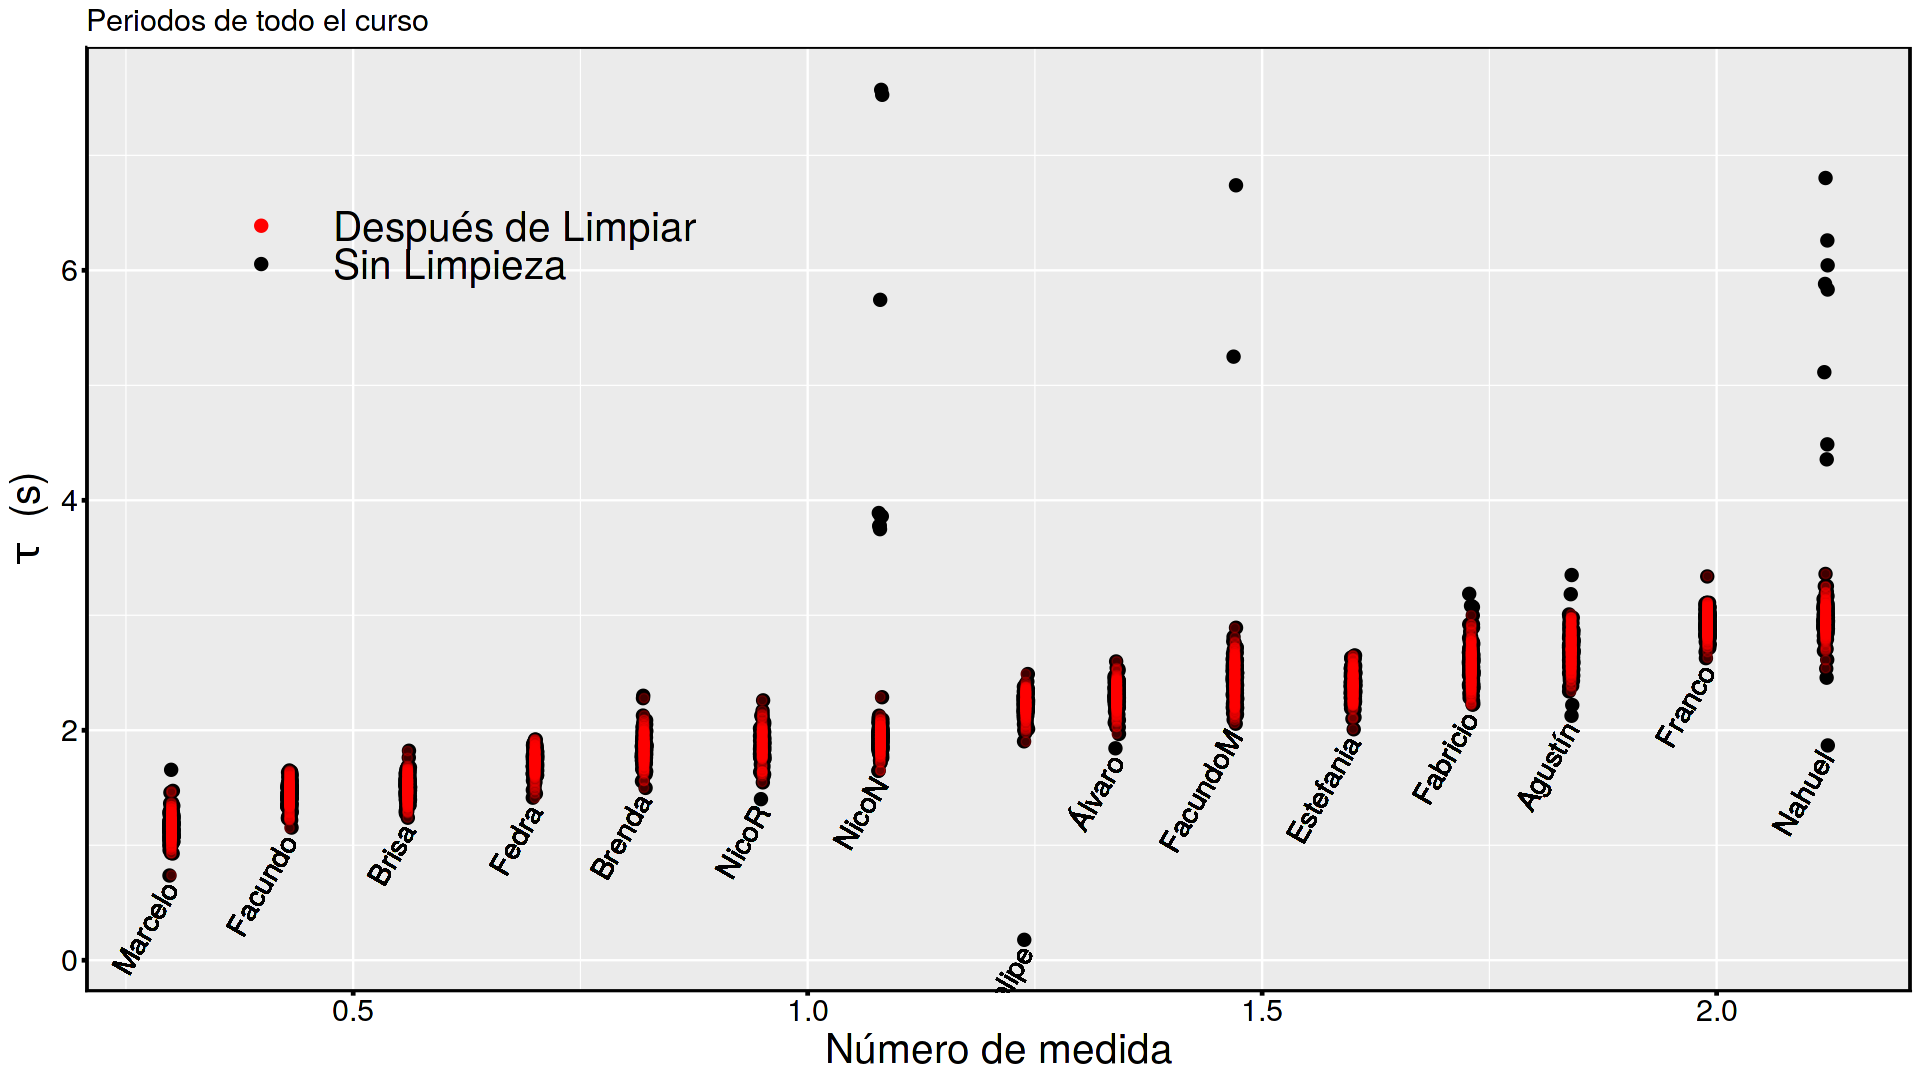

In [25]:
gdt <- ggplot() + 
geom_point(data = dt, aes(x = l, y = T, colour = "Sin Limpieza"),position = position_jitter(0.0025), size = 3) + 
geom_point(data = dt_limpio, aes(x = l, y = T, colour = "Después de Limpiar"), size = 2, alpha = 0.25) +
geom_text(data = dt_limpio, aes(x = l, y = minT, angle = 60, label = Nombre), size = 6, hjust = 1, nudge_y = -0.075) +  
scale_colour_manual(values = c("Después de Limpiar"="Red", "Sin Limpieza" = "Black"), name = NULL, ) + 
ylab(TeX("$\\tau \\; (s)$")) + xlab("Número de medida") + ggtitle("Periodos de todo el curso") + 
temajuan + theme(legend.direction = "vertical", legend.position = c(0.2,0.8))

fig(16,9)
gdt

Vemos que:

* El método para limpiar con mediana(taus) +- 0.15s funciona muy bien, y nos saca los valores de las colas.

* El gráfico ahora se puede hacer más bonito.

# Gráfico modelo todos los puntos

In [26]:
#modelo con la raga
gRAGA <- 9.79316985

l <- seq(0.25,2.1,0.01)
tau_modelo <- 2*pi*sqrt(l/gRAGA)

modelo <- data.frame(l, tau_modelo)

In [27]:
dirGraf

[1] "/home/juan/Documentos/Docencia/FEXPgit/FexpI/Análisis de Datos/Labo2/Graf/"

In [28]:
dirGraf2 <- "/home/juan/Documentos/Docencia/fexpi/2024/DatosLabo2/Graf/"
setwd(dirGraf2)

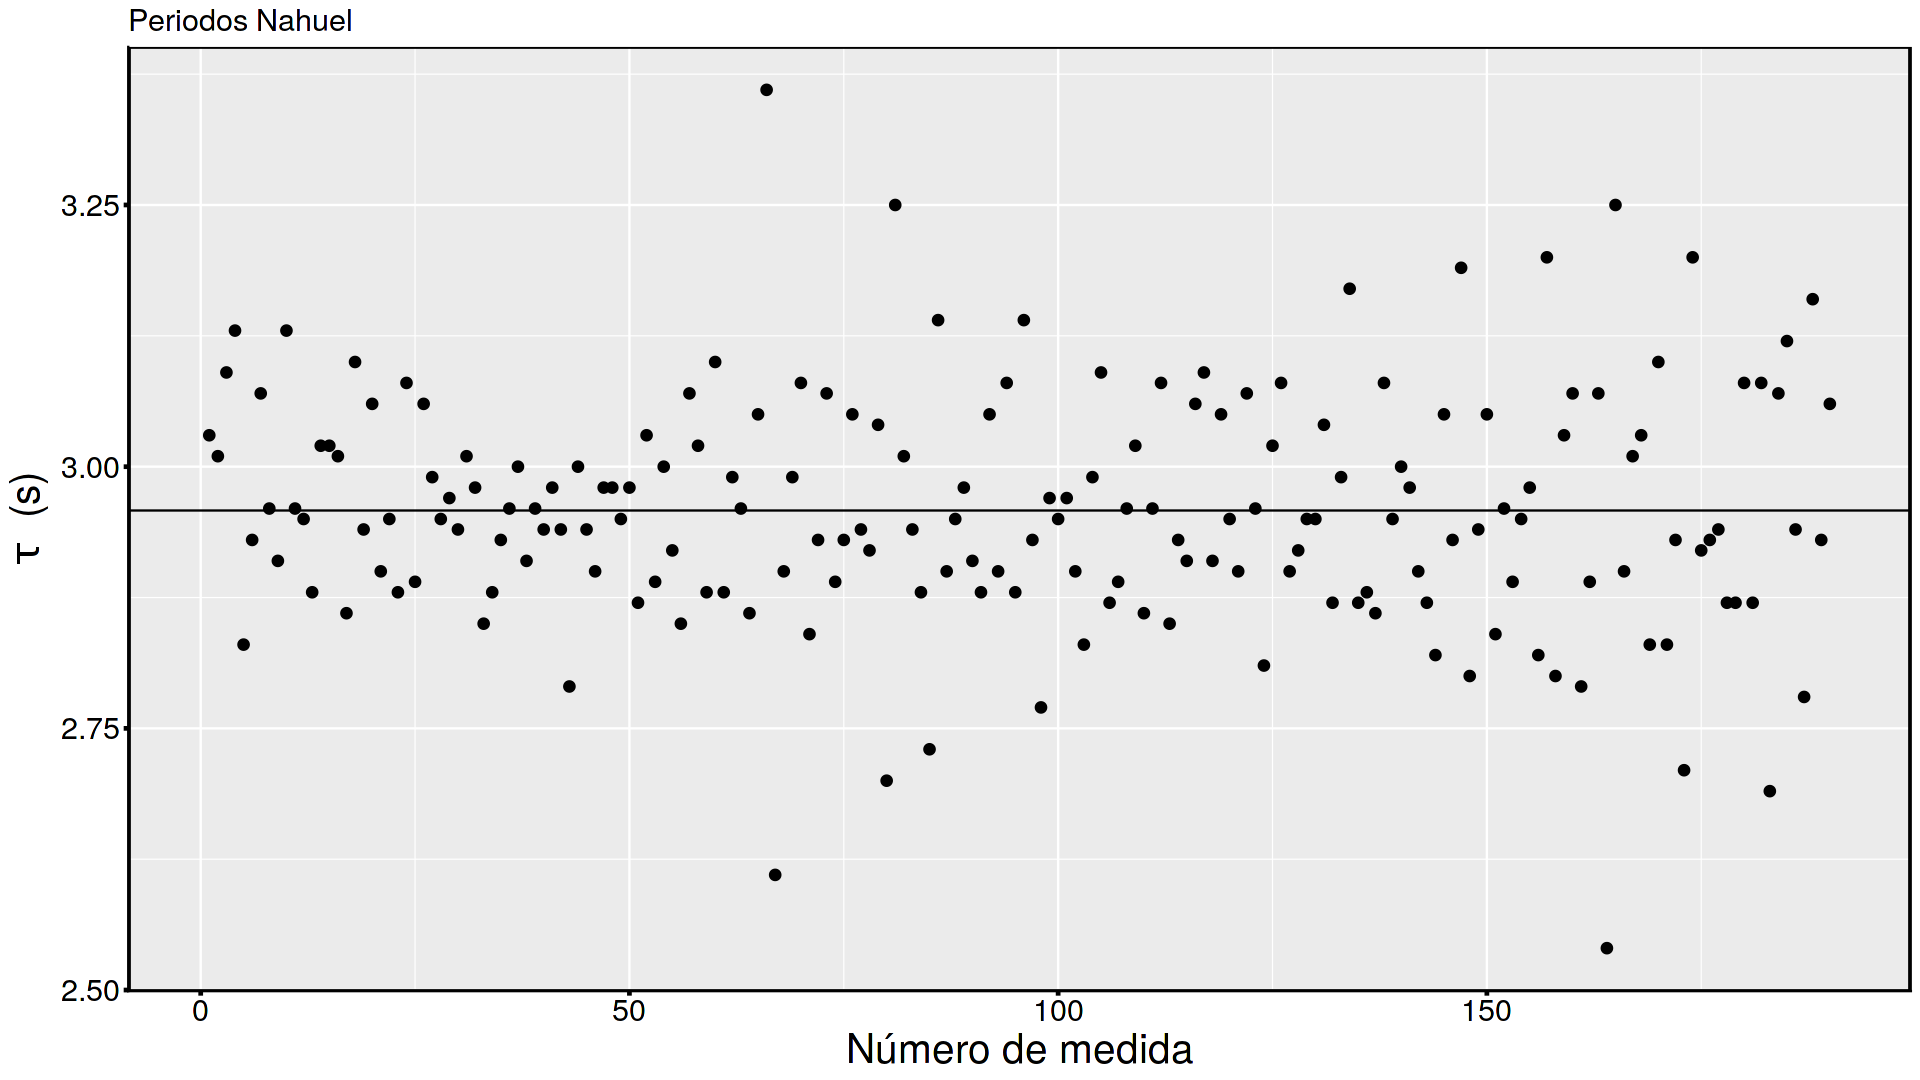

In [29]:
for(i in 1:length(Nombres)){

d <- dt_limpio[dt_limpio$Nombre == Nombres[i], ];
gd <- ggplot(data = d) + 
geom_point(aes(x = n, y = T), size = 2.5) +
geom_hline(aes(yintercept = mean(T) )) +

ylab(TeX("$\\tau \\; (s)$")) + xlab("Número de medida") + 
ggtitle(paste("Periodos", Nombres[i])) + 
temajuan

ggsave(gd,filename = paste("g_dis_",Nombres[i]) ,device = "pdf", width = 12, height = 9)

}

gd

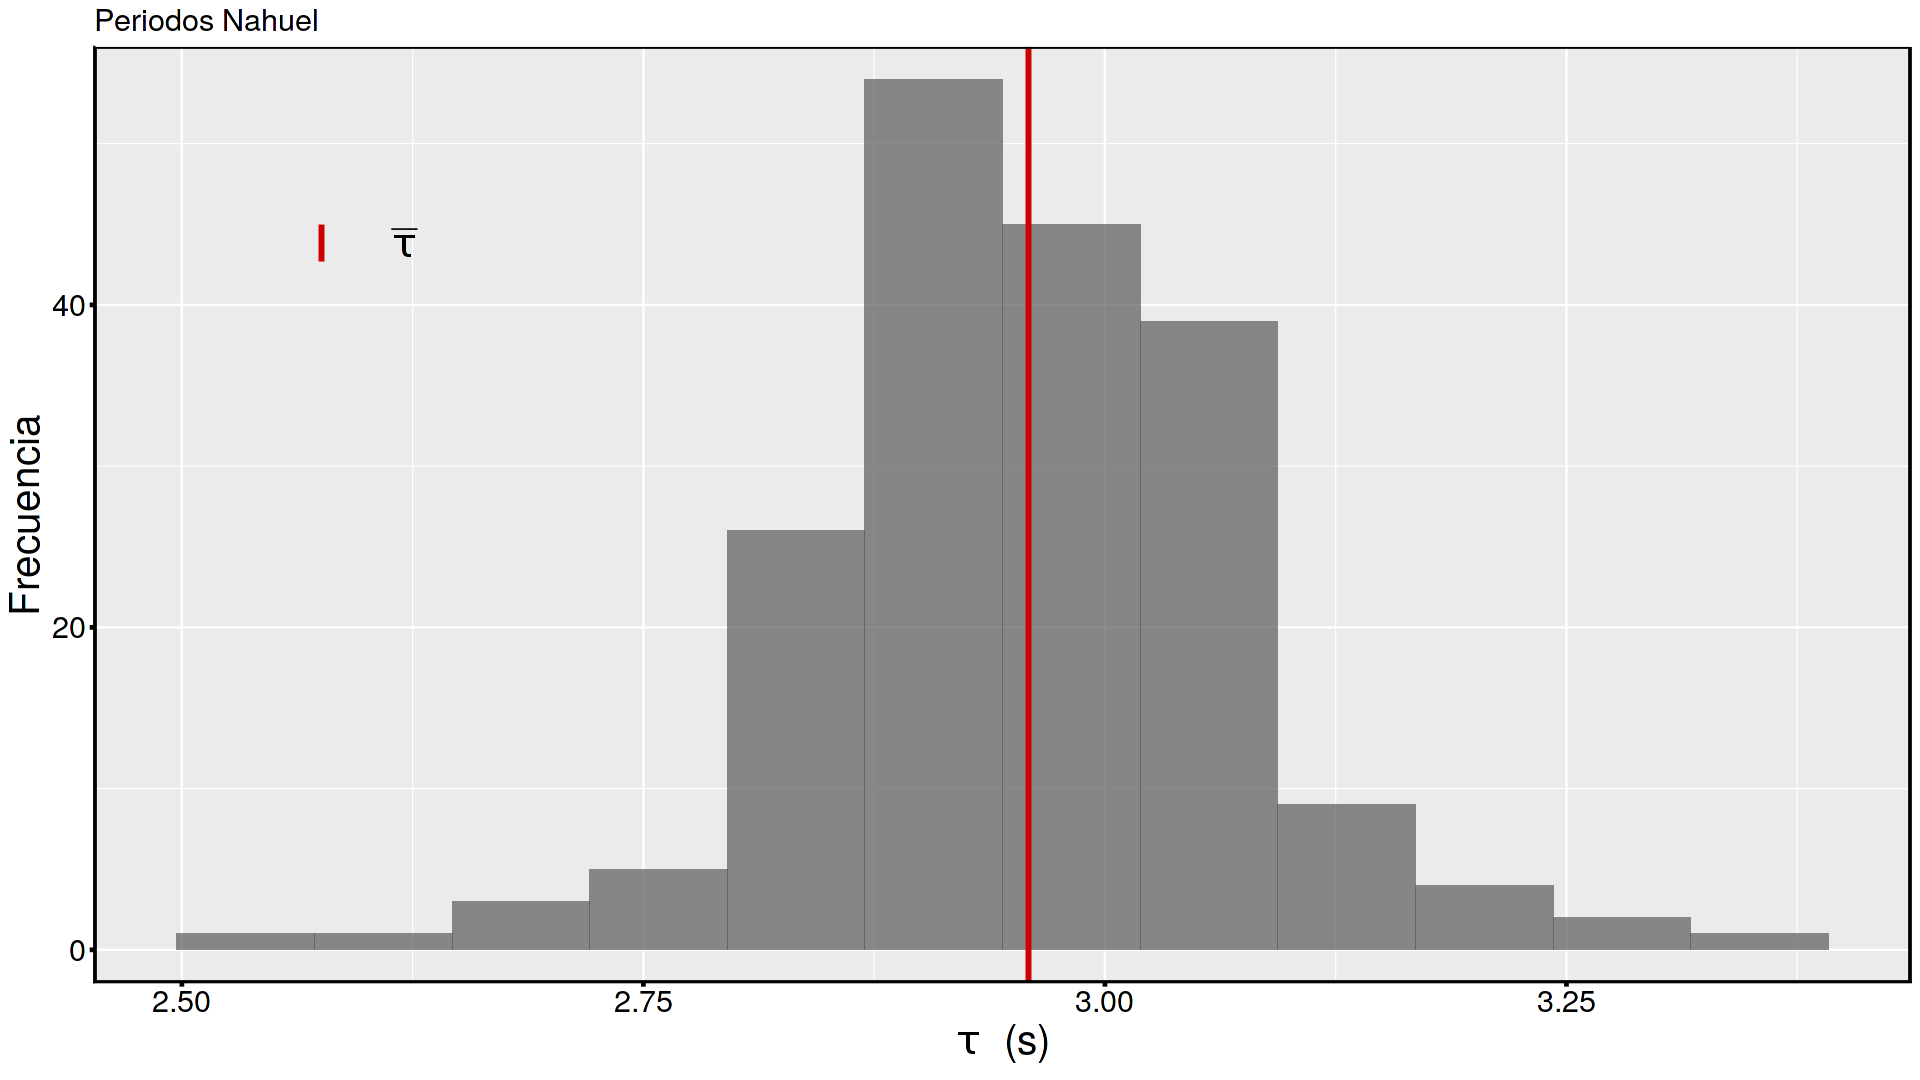

In [34]:
for(i in 1:length(Nombres)){

#partimos dataframe por persona    
d <- dt_limpio[dt_limpio$Nombre == Nombres[i], ];

#graficamos
ghisto <- ggplot(data = d) + 
geom_histogram(aes(x = T), bins = nclass.scott(d$T) ,alpha = 0.7) +
geom_vline(aes(xintercept = mean(T), colour = "media" ), lwd = 1.25) +
scale_colour_manual(breaks = "media", values = "Red3", labels = unname(TeX("$\\bar{\\tau}$")), name = NULL) + 
scale_y_continuous(expand = c(0,2)) + 
xlab(TeX("$\\tau \\; (s)$")) + ylab("Frecuencia") + 
ggtitle(paste("Periodos", Nombres[i])) + 
temajuan

#guardamos    
ggsave(ghisto,filename = paste("g_histo_",Nombres[i]) ,device = "pdf", width = 12, height = 9)

}

ghisto #corroboramos que el último se vea bien

****
****
Ya tenemos todos los gráficos de todo el curso para la medida de $\tau$, están todos limpios y en pdf.

Ahora vamos a explorar las primeras estimaciones de $g$.

****
****

# Tabla de datos para todo el curso

In [171]:
l         <- vector(mode = "numeric", length = length(nombres));
tau_medio <- vector(mode = "numeric", length = length(nombres));
sd_tau    <- vector(mode = "numeric", length = length(nombres));
SEM_tau   <- vector(mode = "numeric", length = length(nombres));

for(i in 1:length(Nombres)){
d <- dt_limpio[dt_limpio$Nombre == Nombres[i], ];

l[i] <- d$l[1]    
tau_medio[i] <- mean(d$T);
sd_tau[i]    <- sd(d$T);
SEM_tau[i]   <- sd_tau[i] / sqrt(length(d$T))    
}

dr <- data.frame(Nombre = Nombres,lcm = l, tau_medio, sd_tau, SEM_tau); head(dr,15);

,Nombre,lcm,tau_medio,sd_tau,SEM_tau
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,Marcelo,0.30,1.155850,0.09375622,0.006629566
2,Facundo,0.43,1.443586,0.08588607,0.006103657
3,Brisa,0.56,1.498400,0.09048968,0.006398587
4,Fedra,0.70,1.726410,0.08390247,0.006008381
5,Brenda,0.82,1.844406,0.10595171,0.007454736
6,NicoR,0.95,1.872149,0.12443343,0.011312130
7,NicoN,1.08,1.928220,0.08456062,0.006118592
8,Felipe,1.24,2.232900,0.08214823,0.005808757
9,Álvaro,1.34,2.304472,0.09635581,0.006830482


Vemos que:

* La asunción de los $\tau$'s medidos es que no tenemos mucho sesgo que digamos, por la manera en la que medimos.

* La sd de la distribución de taus es proporcional al tiempo de respuesta de cada une de ustedes...Felipe y Facundo son extremales en esta población.


## Calculando g
Según el modelo de péndulo ideal, tenemos que $g$ se puede escribir como:

$$
g = 4\pi^2 \frac{l_{cm}}{\tau^2}
$$

su incerteza será:

$$
\delta g =  4\pi^2 \frac{1}{\tau^2} \delta l_{cm} + 2\pi^2 \frac{l_{cm}}{\tau^3} SEM_\tau
$$


In [173]:
dr$dlcm <- rep(0.001, nrow(dr)) # la incerteza de escala en l
head(dr,3)

,Nombre,lcm,tau_medio,sd_tau,SEM_tau,dlcm
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Marcelo,0.30,1.155850,0.09375622,0.006629566,0.001
2,Facundo,0.43,1.443586,0.08588607,0.006103657,0.001
3,Brisa,0.56,1.498400,0.09048968,0.006398587,0.001


In [203]:
dr$g_modelo <- 4*pi^2*(dr$lcm / dr$tau_medio^2);

dr$sg <- 4*pi^2* (1/(dr$tau_medio^2) * dr$dlcm + 0.5* (dr$lcm / dr$tau_medio^3)* dr$SEM_tau)
dr$discrepancia <- 9.79316985 - dr$g_modelo;
head(dr,15)


,Nombre,lcm,tau_medio,sd_tau,SEM_tau,dlcm,g_modelo,sg,discrepancia,x
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Marcelo,0.30,1.155850,0.09375622,0.006629566,0.001,8.864986,0.05497324,0.92818420,0.5477226
2,Facundo,0.43,1.443586,0.08588607,0.006103657,0.001,8.145973,0.03616521,1.64719708,0.6557439
3,Brisa,0.56,1.498400,0.09048968,0.006398587,0.001,9.846735,0.03860761,-0.05356481,0.7483315
4,Fedra,0.70,1.726410,0.08390247,0.006008381,0.001,9.271922,0.02938002,0.52124801,0.8366600
5,Brenda,0.82,1.844406,0.10595171,0.007454736,0.001,9.516134,0.03083624,0.27703551,0.9055385
6,NicoR,0.95,1.872149,0.12443343,0.011312130,0.001,10.700465,0.04359148,-0.90729470,0.9746794
7,NicoN,1.08,1.928220,0.08456062,0.006118592,0.001,11.467543,0.02881239,-1.67437304,1.0392305
8,Felipe,1.24,2.232900,0.08214823,0.005808757,0.001,9.818449,0.02068916,-0.02527883,1.1135529
9,Álvaro,1.34,2.304472,0.09635581,0.006830482,0.001,9.961426,0.02219679,-0.16825648,1.1575837


In [187]:
gg <- ggplot(data = dr) + 

geom_pointrange(aes(x = Nombre, y = g_modelo, ymin = g_modelo -dg, ymax  = g_modelo + dg )) + 
geom_hline(aes(yintercept = 9.79316985, colour = "graga")) +
scale_colour_manual(values = "Black", breaks = "graga", labels = unname(TeX("$g_{RAGA}$")), name = NULL ) + 
ylab(TeX("$g \\; (m \\, s^{-2})$")) + ggtitle("Estimaciones de g para cada persona del curso") + 
temajuan + theme(legend.position = c(0.8,0.8), axis.text.x =  element_text(angle = 45, hjust = 1, ))  

ggsave(gg, filename = "g_por_persona.pdf", device = "pdf", width = 12, height = 9)

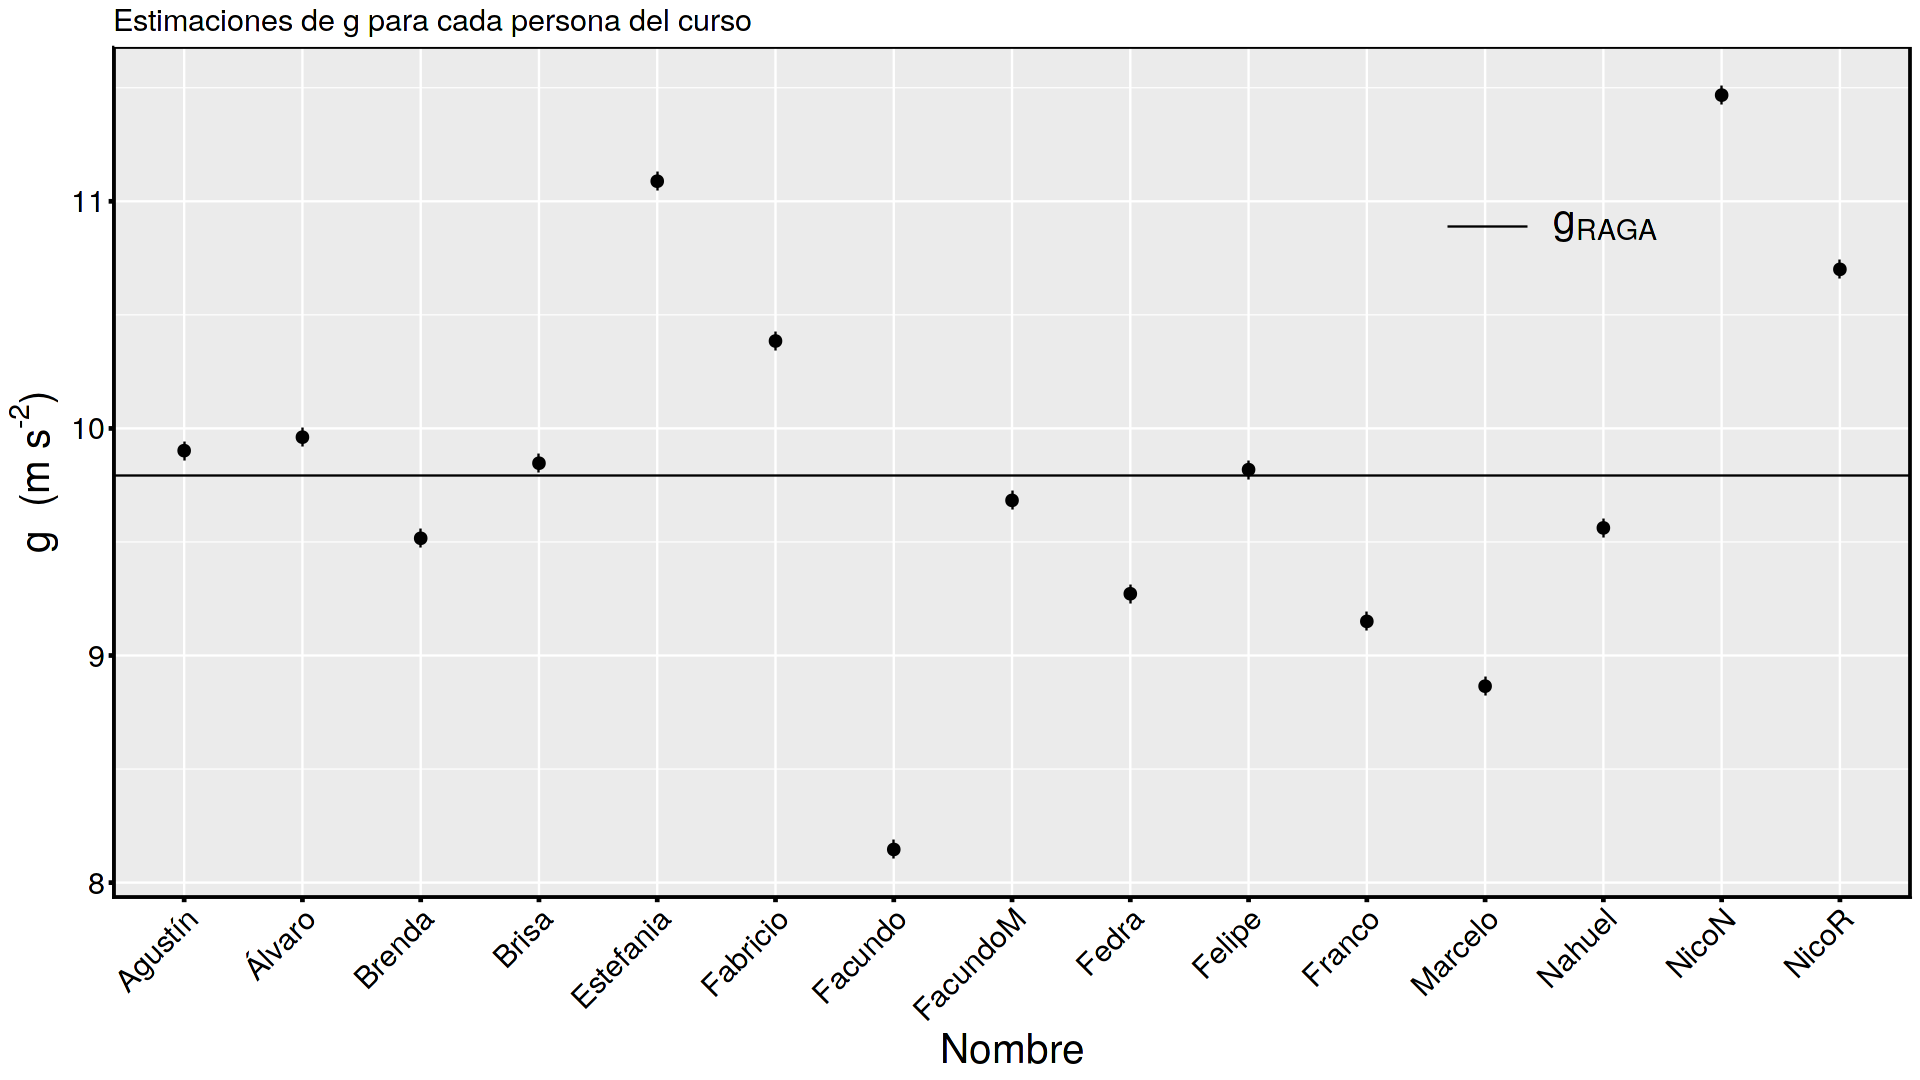

In [188]:
fig(16,9)
gg

Lo que vemos en el gráfico:

* Todos los puntos están relativamente cerca de la RAGA, salvo Facundo, Nico Navratil, Estefanía, Nico Rogel...

Bueno, las estimaciones buenas son las de: Felipe, FacuM, Brisa y Agustí (mirar tabla).

   * ¿A cuál de las medidas (periodo o largo del péndulo) se debe esto?
   * Cuánto deberíamos movernos de los valores de lcm informados para llegar a estimaciones perfectas?

#### Gráfico $\tau \; vs. \; l$ contrastado con el modelo de la RAGA

In [191]:
#modelo con la raga
gRAGA <- 9.79316985

l <- seq(0.25,max(dr$lcm) + 0.05 ,0.01)
tau_modelo <- 2*pi*sqrt(l/gRAGA)

modelo <- data.frame(l, tau_modelo)

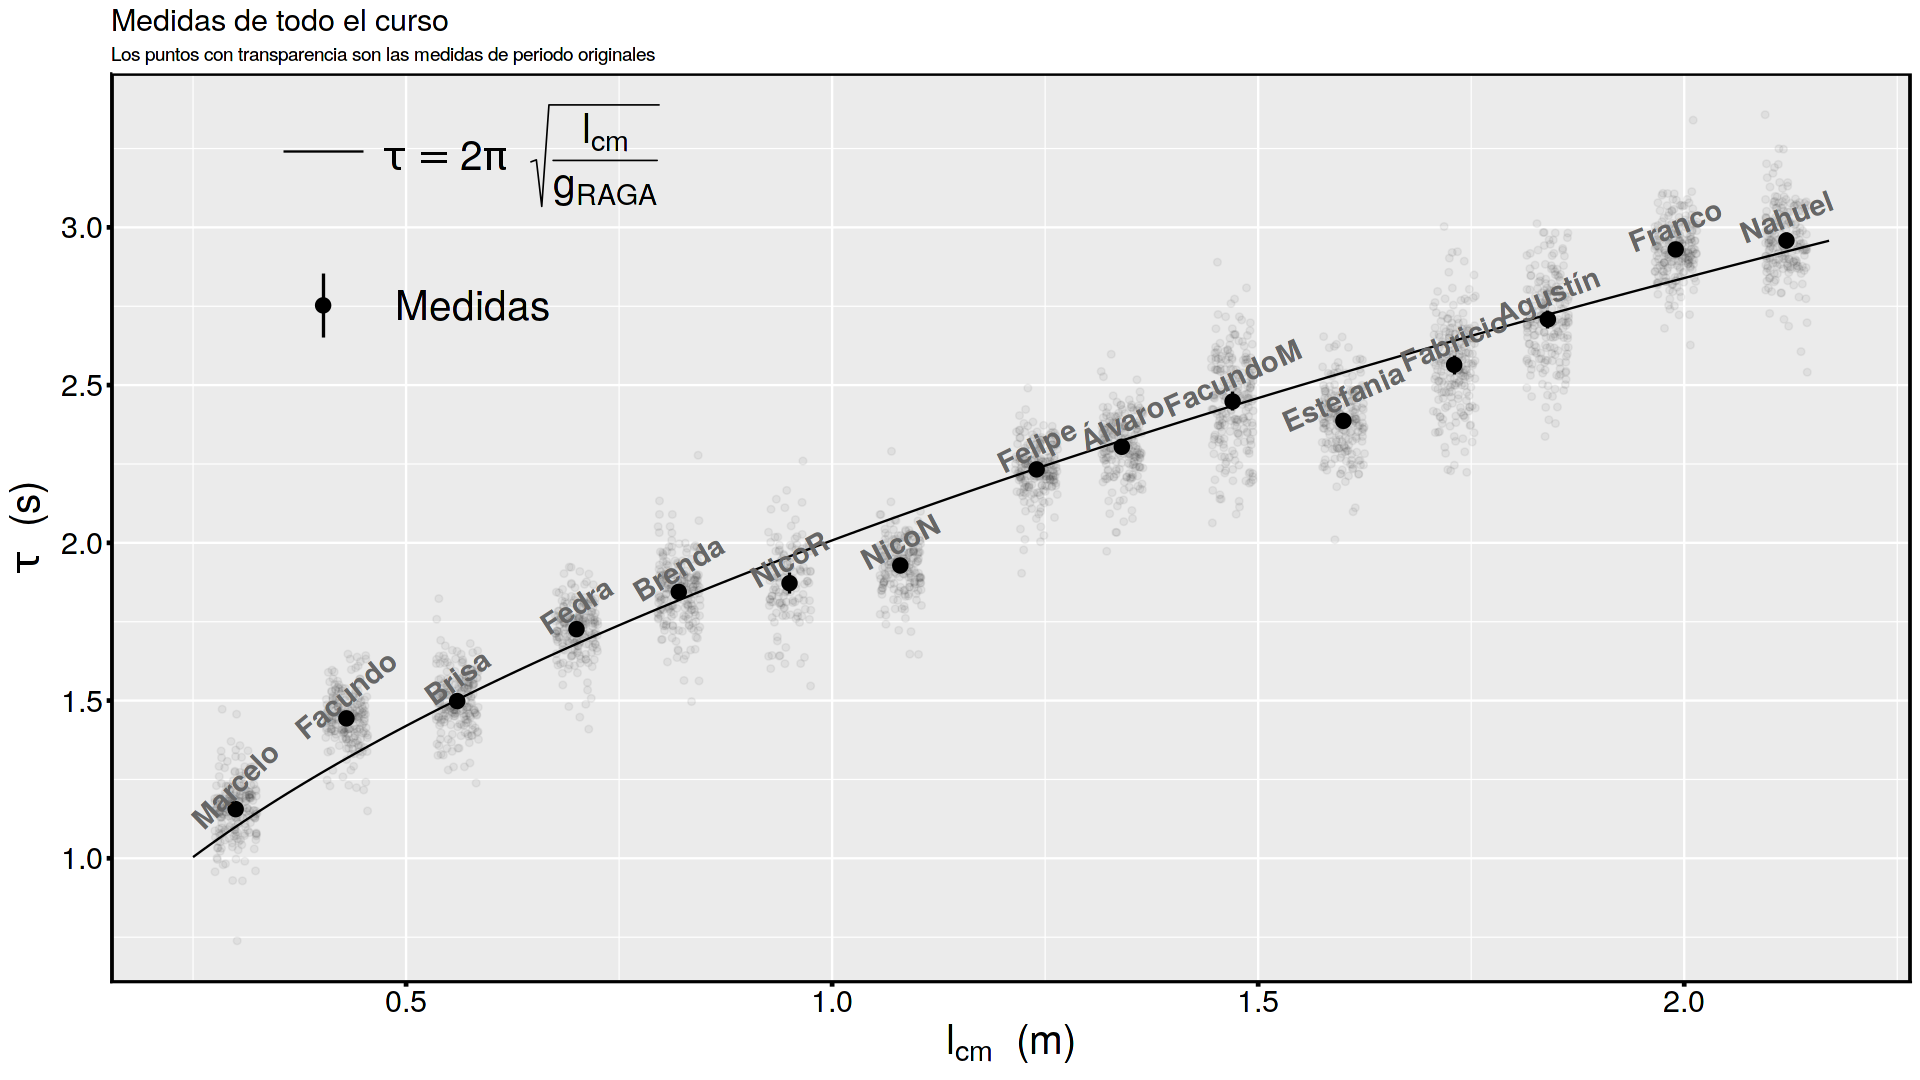

In [209]:
gtutti <- ggplot() + 

geom_pointrange(data = dr, aes(x = lcm, y = tau_medio, ymin = tau_medio - 3*SEM_tau, ymax  =  tau_medio + 3* SEM_tau, size = "Medidas"  )) + 
geom_point(data = dt_limpio, aes(x = l, y = T), alpha = 0.05, position = position_jitter(0.025)) + 
geom_line(data = modelo, aes(x = l, y = tau_modelo, colour = "mod")) + 
geom_text(data = dr, aes(x = lcm, y = tau_medio, label = Nombre),
           colour = "Gray40", fontface = "bold", size = 6, 
           nudge_x = 0, nudge_y = 0.0750, hjust = 0.5,angle = atan(0.5 * dr$lcm^(-0.5))*180/pi + 2) +
scale_colour_manual(name = NULL, values = "Black", breaks = "mod", labels = unname(TeX("$\\tau = 2\\pi\\;\\sqrt{\\frac{l_{cm}}{g_{RAGA}}}$"))) + 
scale_size_manual(name = NULL, breaks = "Medidas", values = 0.7) + 

xlab(TeX("$l_{cm} \\; (m) $")) + ylab(TeX("$\\tau \\; (s)$")) +
ggtitle("Medidas de todo el curso", subtitle = "Los puntos con transparencia son las medidas de periodo originales con un ruido agregado para ")+


temajuan + theme (legend.position = c(0.2,0.85), legend.box = "vertical", legend.key.height = unit(0.1,"snpc"))

gtutti

ggsave(gtutti, filename = "g_tau_vs_l_curso_entero.pdf", width = 12, height = 9, device = "pdf")

En este gráfico vemos que:

* A medida que aumenta $l_{cm}$ aumenta $\tau$, y el comportamiento de $\tau \propto \sqrt{l}$ se aprecia, aunque no tan bien como en años anteriores. Las medidas del largo están sesgadas por todos lados, y hay algunas que parecen inventadas (hablemus claro!).

* Las nubes de puntos son todas las medidas de periodos, con cierto ruido agregado en el eje horizontal para que se vea la cantidad de puntos involucrados. Es para que se vea cómo resumimos datos.

* Las barras que marcan el $SEM_\tau$ no se aprecian debido a los valores pequeños del mismo.

* En cuanto a los puntos, sólo el de Luis presenta mayor sesgo.

* La curva del modelo en este gráfico es un parteaguas:

     * Puntos arriba sobreestiman $g_{RAGA}$
     
     * Puntos debajo subestiman $g_{RAGA}$.


****
****
# Cambio de escala y Ajustes lineales

Bueno, esto es un truco viejo:

Ya que en los puntos de $\tau$ versus $l_{cm}$ lo que buscamos el modelo $\tau = \big(2\pi/\sqrt{g}\big)\sqrt{l}$, la idea sería tener algún método que nos encuentre un *ajuste de g* a partir de los datos que tenemos, $(l_{cm \; i \;\;}, \tau_{i})$...sin embargo ese método está fuera de nuestro alcance.

Lo que sabemos de la teoría es que se pueden ajustar rectas, es decir, podríamos tener relaciones funcionales de $\tau$ de la forma: 

$$\tau = a + bx$$

ó, sin ordenada al origen, $$\tau = bx$$

Esto, en principio, nos deja cortos de métodos...

Sin embargo, podemos linealizar, es decir, buscar un cambio de escala para que la ecuación **se vea como una recta** en la nueva escala. Es claro que si los puntos experimentales se portan como dice el modelo, entonces también los puntos se van a *alinear* (dependiendo del sesgo y los ruidos) con el cambio de escala.

El cambio de escala típico en este caso es:

$$
\tau = \big(2\pi/\sqrt{g}\big)\sqrt{l} = \begin{cases}
    \tau &\rightarrow \tau  \\ % & is your "\tab"-like command (it's a tab alignment character)
    l_{cm} &\rightarrow x = \sqrt{l_{cm}} 
\end{cases} \; \Rightarrow \;\; \\ \boxed{ \tau = \big(2\pi/\sqrt{g}\big) x} \Rightarrow \\ \; \; \\ \tau =  b x \; \text{ siendo } \; b = \big(2\pi/\sqrt{g}\big)
$$

Entonces tenemos que, al graficar $\tau$ vs. $x = \sqrt{l}$, deberíamos tener una recta para el modelo.

Esto nos permitirá usar ajustes lineales para estimar *relaciones tipo rectas* en los puntos, más allá del modelo.

In [208]:
getwd()

[1] "/home/juan/Documentos/Docencia/fexpi/2024/DatosLabo2/Todos"

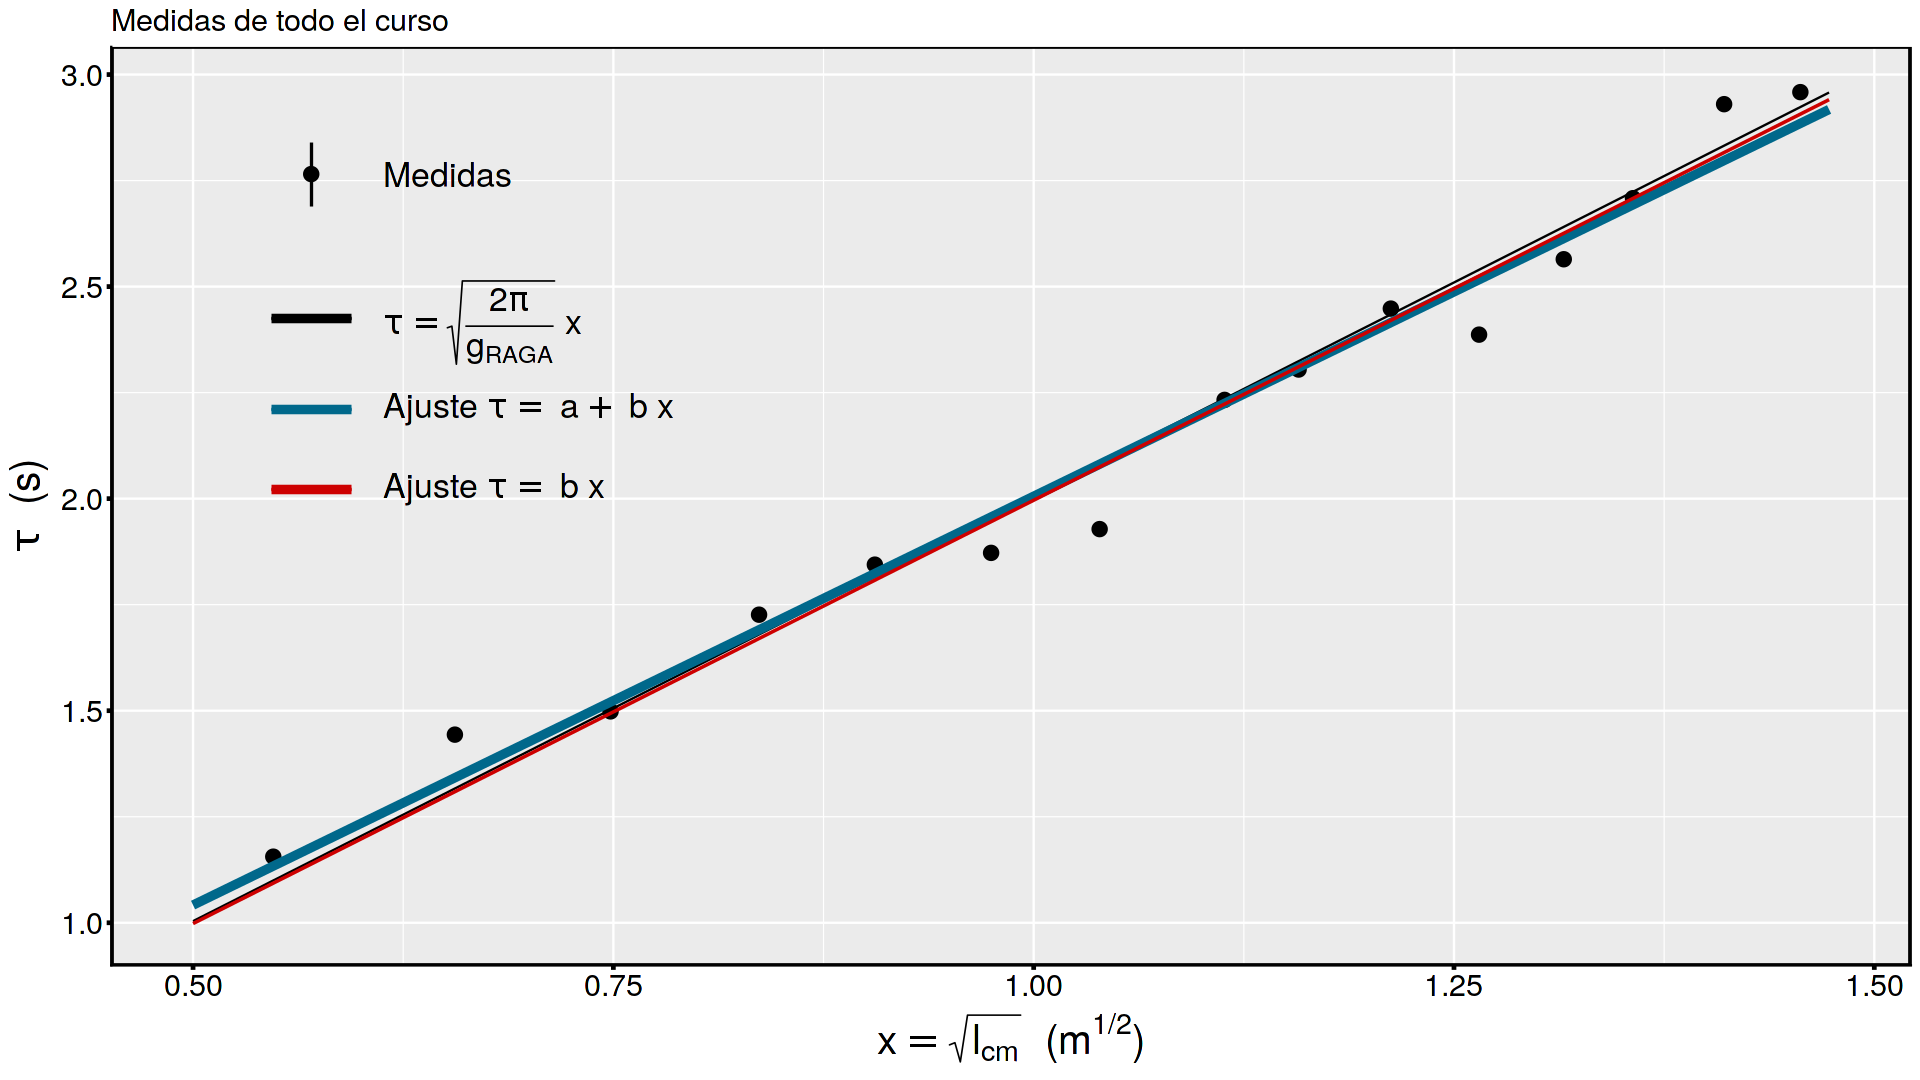

In [206]:
dr$x <- sqrt(dr$lcm)
modelo$x <- sqrt(modelo$l)

gescala <- ggplot() + 

geom_pointrange(data = dr, aes(x = x, y = tau_medio, ymin = tau_medio - SEM_tau, ymax  =  tau_medio + SEM_tau, size = "Medidas" )   ) + 
geom_line(data = modelo, aes(x = x, y = tau_modelo, colour = "mod")) + 
geom_smooth(data = dr, aes(x = x, y = tau_medio, colour = "ab"),alpha = 0.01,lwd = 2,fullrange = T , method = "lm", formula = "y ~ x", se = F) + 
geom_smooth(data = dr, aes(x = x, y = tau_medio, colour = "b"), alpha = 0.25, lwd = 0.75,fullrange = T , method = "lm", formula = "y ~ 0 + x", se = F) + 
scale_colour_manual(name = NULL, values = c("Black", "Deepskyblue4", "Red3"),
                    breaks = c("mod", "ab", "b"),
                    labels = unname(c(TeX("$\\tau = \\sqrt{\\frac{2\\pi\\}{g_{RAGA}}} \\, x$"),
                                      TeX("Ajuste $\\tau = \\, a  +\\, b\\, x$"),TeX("Ajuste $\\tau =\\, b\\, x$")) )) + 
scale_size_manual(name = NULL, breaks = "Medidas", values = 0.7) + 

xlab(TeX("$x = \\sqrt{l_{cm}} \\; (m^{1/2}) $")) + ylab(TeX("$\\tau \\; (s)$")) + ggtitle("Medidas de todo el curso")+
#scale_x_continuous(trans = "sqrt", ) + 

temajuan + theme (legend.position = c(0.2,0.7),
                  legend.key.height = unit(0.1,"snpc"), 
                  legend.text = element_text(size = 20, hjust = 0),
                  legend.box = "vertical"    
                
                 )

gescala

ggsave(gescala, filename = "g_escala_raiz.pdf", width = 12, height = 9, device = "pdf")

En el gráfico vemos que:

* Los puntos se alinean a simple vista, lo cual nos deja bien parada la ec. del péndulo.

* Todos los ajustes (y el modelo de la RAGA) parecen bien a simple vista, aunque tienen pequeñas diferencias en las pendientes.

La evaluación visual es buena en todo aspecto, aunque siempre quedan detalles...

Si vemos los valores numéricos de los ajustes...

In [207]:
#tabla de ajustes
b <-  lm(dr$tau_medio ~ 0 + dr$x) #ajuste tau = bx
ab <- lm(dr$tau_medio ~ dr$x)         #ajuste tau = a + b

rb <- summary.lm(b)
rab <- summary.lm(ab)

tipo <- c("y = a + b x", "y = 0 + b x")
a    <- c(rab$coefficients[1,1], NA)
sa   <- c(rab$coefficients[1,2], NA)
b    <- c(rab$coefficients[2,1],rb$coefficients[1,1])
sb   <- c(rab$coefficients[2,2], rb$coefficients[1,2] )
R2  <- c(rab$r.squared, rb$r.squared)

ajustes <- data.frame(tipo, a, sa, b, sb, R2);
ajustes[ , 2:6] <- round(ajustes[ , 2:6], 5) 
cat("Ajustes: \n")
head(ajustes)

Ajustes: 


,tipo,a,sa,b,sb,R2
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,y = a + b x,0.07783,0.08544,1.92784,0.07763,0.97936
2,y = 0 + b x,NA,NA,1.99635,0.01911,0.99872


La columna **a** son las ordenadas al origen; la **b** son las pendientes. Ambas columnas tienen desviaciones estándar asociadas, **sa** y **sb**. La columna **R2** es lo que se conoce como $R^2$ y es un parámetro que indica buenos ajustes si está cerca de 1 y malos si está cerca de 0.

Sin embargo, no podemos evaluar la tabla sin calcular una aceleración de la gravedad a partir de cada ajuste.

#### Cómo estimar g a partir de los ajustes?

La idea es simple: identificamos parámetros en las ecuaciones del cambio de escala y obtenemos:

$$
b = 2\pi / \sqrt{g} \Rightarrow g = \frac{4 \pi^2}{b^2}
$$

las incertezas de estimación de g, dado que la pendiente se obtiene con una desviación estándar, ($b \pm s_b$), es:

$$
s_g = \frac{8\pi^2}{b^3}s_b
$$

In [196]:
ajustes$g  <- 4*pi^2 / ajustes$b^2
ajustes$sg <- 8*pi^2 / ajustes$b^3 * ajustes$sb;
head(ajustes)

,tipo,a,sa,b,sb,R2,g,sg
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,y = a + b x,0.07783,0.08544,1.92784,0.07763,0.97936,10.622280,0.8554731
2,y = 0 + b x,NA,NA,1.99635,0.01911,0.99872,9.905727,0.1896446


Vemos que:

Los valores de $g$ están cerca, pero no son $g_{RAGA}\;$. Esto puede tener muchas explicaciones, pero difícilmente podamos evaluarlas sin hacer el experimento con más cuidado.
***
***

## Concluyendo:

### Medida de $\tau$

**Las medidas siempre se limpian de valores atípicos o anómalos**, los métodos brutos funcionan bien para casos simples, métodos un poquito más sofisticados mejoran la vida con casos más complejos.

La medida de $\tau$ no tiene sesgo hecho por el método de medida, y si bien la amplitud influye un poco, la influencia es mucho más chica que la precisión con la que medimos.

### Medida de $l_{cm}$

Esta es la medida difícil de sacar sin sesgo...porque la cinta siempre cae un poco abajo o arriba de un centro de masa siempre inventado.
### Modelo utilizado

La comparación visual da muy bien, para el modelo y los ajustes. Esto quiere decir que el modelo funciona, a pesar de que la determinación de $g$ no está tan cerca del valor de la RAGA, el modelo describe bien los datos.

Para hacer determinaciones que estén más cerca de la RAGA deberemos estar más seguros de las medidas de $l_{cm}$ y $\tau$:

* Para $l_{cm}$ deberemos ver los posibles sesgos con cuidado.

* Para $\tau$ deberíamos mantener todas las amplitudes de oscilación pequeñas, y en lo posible cuantificar cuánto cambia en el modelo el valor de $\tau$ para amplitudes grandes.